<a href="https://colab.research.google.com/github/Mahimajha07/EUTO-SAT---land-cover-classification-/blob/main/SAR_to_optical_image_translation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("requiemonk/sentinel12-image-pairs-segregated-by-terrain")

Using Colab cache for faster access to the 'sentinel12-image-pairs-segregated-by-terrain' dataset.


In [2]:
import os

print("Dataset path:", path)
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files", dirs[:5])
    if root.count(os.sep) - path.count(os.sep) > 2:
        break

Dataset path: /kaggle/input/sentinel12-image-pairs-segregated-by-terrain
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain -> 0 files ['v_2']
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2 -> 0 files ['agri', 'urban', 'barrenland', 'grassland']
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri -> 0 files ['s1', 's2']
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1 -> 4000 files []


In [3]:
import tensorflow as tf

IMG_SIZE = 256

def load_pair(sar_path, optical_path):
    sar_img = tf.io.read_file(sar_path)
    sar_img = tf.image.decode_jpeg(sar_img, channels=3)
    sar_img = tf.image.resize(sar_img, [IMG_SIZE, IMG_SIZE])

    optical_img = tf.io.read_file(optical_path)
    optical_img = tf.image.decode_jpeg(optical_img, channels=3)
    optical_img = tf.image.resize(optical_img, [IMG_SIZE, IMG_SIZE])


    sar_img = (sar_img / 127.5) - 1
    optical_img = (optical_img / 127.5) - 1
    return sar_img, optical_img

print("Loader defined — will wire up real file paths once we see your dataset structure")

Loader defined — will wire up real file paths once we see your dataset structure


In [4]:
from tensorflow.keras import layers

def downsample(filters, size, apply_batchnorm=True):
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding="same",
                              kernel_initializer=tf.random_normal_initializer(0., 0.02),
                              use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding="same",
                                       kernel_initializer=tf.random_normal_initializer(0., 0.02),
                                       use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

def build_generator():
    inputs = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])

    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4), downsample(256, 4), downsample(512, 4),
        downsample(512, 4), downsample(512, 4), downsample(512, 4), downsample(512, 4),
    ]
    up_stack = [
        upsample(512, 4, apply_dropout=True), upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True), upsample(512, 4),
        upsample(256, 4), upsample(128, 4), upsample(64, 4),
    ]

    last = layers.Conv2DTranspose(3, 4, strides=2, padding="same",
                                   kernel_initializer=tf.random_normal_initializer(0., 0.02),
                                   activation="tanh")

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

generator = build_generator()
generator.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │      3,072 │ input_layer[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │    131,584 │ sequential[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    525,312 │ sequential_1[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 16, 16,    │  2,099,200 │ sequential_2[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 8, 8, 512) │  4,196,352 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 4, 4, 512) │  4,196,352 │ sequential_4[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 2, 2, 512) │  4,196,352 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 1, 1, 512) │  4,196,352 │ sequential_6[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 2, 2, 512) │  4,196,352 │ sequential_7[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 2,      │          0 │ sequential_8[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 4, 4, 512) │  8,390,656 │ concatenate[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4, 4,      │          0 │ sequential_9[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 8, 8, 512) │  8,390,656 │ concatenate_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8,      │          0 │ sequential_10[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_11       │ (None, 16, 16,    │  8,390,656 │ concatenate_2[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ sequential_11[0]

 Total params: 54,425,859 (207.62 MB)

 Trainable params: 54,414,979 (207.58 MB)

 Non-trainable params: 10,880 (42.50 KB)

In [5]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA = 100

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)
    return total_gen_loss, gan_loss, l1_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    return real_loss + generated_loss

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def train_step(input_image, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)
        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))

    return gen_total_loss, disc_loss

In [6]:
import os

s2_dir = os.path.join(path, "v_2", "urban", "s2")
s1_dir = os.path.join(path, "v_2", "urban", "s1")

print("Sample s2 (optical) files:", os.listdir(s2_dir)[:5])
print("Sample s1 (SAR) files:", os.listdir(s1_dir)[:5])
print("Total s2 files:", len(os.listdir(s2_dir)))
print("Total s1 files:", len(os.listdir(s1_dir)))

Sample s2 (optical) files: ['ROIs1970_fall_s2_43_p644.png', 'ROIs1970_fall_s2_43_p674.png', 'ROIs1970_fall_s2_52_p358.png', 'ROIs1970_fall_s2_67_p855.png', 'ROIs1970_fall_s2_143_p399.png']
Sample s1 (SAR) files: ['ROIs1970_fall_s1_47_p1066.png', 'ROIs1970_fall_s1_56_p237.png', 'ROIs1970_fall_s1_8_p124.png', 'ROIs1970_fall_s1_8_p500.png', 'ROIs1970_fall_s1_50_p105.png']
Total s2 files: 4000
Total s1 files: 4000


In [7]:
import os

TERRAINS = ["urban", "barrenland", "grassland", "agri"]
BASE_DIR = os.path.join(path, "v_2")

def build_pairs(base_dir, terrains):
    sar_paths, optical_paths = [], []
    for terrain in terrains:
        s2_dir = os.path.join(base_dir, terrain, "s2")
        s1_dir = os.path.join(base_dir, terrain, "s1")
        for fname in os.listdir(s2_dir):
            sar_fname = fname.replace("_s2_", "_s1_")
            sar_path = os.path.join(s1_dir, sar_fname)
            if os.path.exists(sar_path):
                sar_paths.append(sar_path)
                optical_paths.append(os.path.join(s2_dir, fname))
    return sar_paths, optical_paths

sar_paths, optical_paths = build_pairs(BASE_DIR, TERRAINS)
print(f"Total matched pairs: {len(sar_paths)}")
print("Example pair:")
print(" SAR:", sar_paths[0])
print(" Optical:", optical_paths[0])

Total matched pairs: 16000
Example pair:
 SAR: /kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/urban/s1/ROIs1970_fall_s1_43_p644.png
 Optical: /kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/urban/s2/ROIs1970_fall_s2_43_p644.png


Train pairs: 14400, Val pairs: 1600


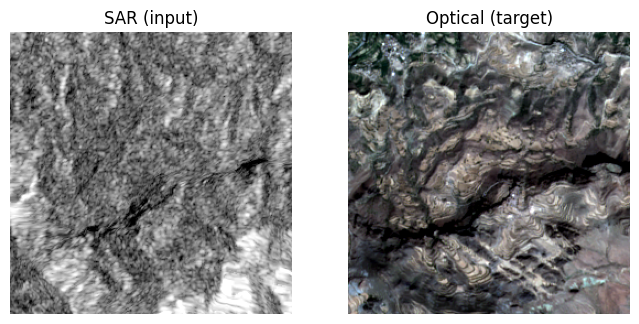

In [8]:
import tensorflow as tf
import numpy as np

IMG_SIZE = 256
BATCH_SIZE = 8

def load_pair(sar_path, optical_path):
    sar_img = tf.io.read_file(sar_path)
    sar_img = tf.image.decode_png(sar_img, channels=3)
    sar_img = tf.image.resize(sar_img, [IMG_SIZE, IMG_SIZE])

    optical_img = tf.io.read_file(optical_path)
    optical_img = tf.image.decode_png(optical_img, channels=3)
    optical_img = tf.image.resize(optical_img, [IMG_SIZE, IMG_SIZE])

    sar_img = (tf.cast(sar_img, tf.float32) / 127.5) - 1
    optical_img = (tf.cast(optical_img, tf.float32) / 127.5) - 1
    return sar_img, optical_img

sar_paths_arr = np.array(sar_paths)
optical_paths_arr = np.array(optical_paths)

n = len(sar_paths_arr)
idx = np.random.RandomState(42).permutation(n)
split = int(n * 0.9)
train_idx, val_idx = idx[:split], idx[split:]

train_dataset = tf.data.Dataset.from_tensor_slices(
    (sar_paths_arr[train_idx], optical_paths_arr[train_idx])
).map(load_pair, num_parallel_calls=tf.data.AUTOTUNE).shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (sar_paths_arr[val_idx], optical_paths_arr[val_idx])
).map(load_pair, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Train pairs: {len(train_idx)}, Val pairs: {len(val_idx)}")


import matplotlib.pyplot as plt
for sar, optical in train_dataset.take(1):
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1); plt.imshow((sar[0] + 1) / 2); plt.title("SAR (input)"); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow((optical[0] + 1) / 2); plt.title("Optical (target)"); plt.axis("off")
    plt.show()

In [9]:
import os
import tensorflow as tf
from tensorflow.keras import layers




def build_discriminator():
    inputs = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3], name='input_image')
    target_image = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3], name='target_image')

    x = layers.concatenate([inputs, target_image])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = layers.ZeroPadding2D()(down3)
    conv = layers.Conv2D(512, 4, strides=1, kernel_initializer=tf.random_normal_initializer(0., 0.02), use_bias=False)(zero_pad1)

    batchnorm1 = layers.BatchNormalization()(conv)

    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)

    last = layers.Conv2D(1, 4, strides=1, kernel_initializer=tf.random_normal_initializer(0., 0.02))(zero_pad2)

    return tf.keras.Model(inputs=[inputs, target_image], outputs=last)

discriminator = build_discriminator()

checkpoint_dir = "./sar2optical_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator,
)
print("Checkpoint manager ready.")

Checkpoint manager ready.


In [10]:
import matplotlib.pyplot as plt

def generate_and_show(model, sar_input, optical_target, epoch=None):
    prediction = model(sar_input, training=False)
    plt.figure(figsize=(12, 4))
    display_list = [sar_input[0], optical_target[0], prediction[0]]
    titles = ["Input SAR", "Ground Truth Optical", "Generated Optical"]

    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(titles[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis("off")
    if epoch is not None:
        plt.suptitle(f"Epoch {epoch}")
    plt.show()


for fixed_sar, fixed_optical in val_dataset.take(1):
    break


Epoch 1/15 starting...
  batch 0 — gen_loss: 33.9775, disc_loss: 0.3288
  batch 50 — gen_loss: 27.7734, disc_loss: 1.0131
  batch 100 — gen_loss: 40.3658, disc_loss: 0.3225
  batch 150 — gen_loss: 35.7418, disc_loss: 2.1276
  batch 200 — gen_loss: 36.5897, disc_loss: 0.2368
  batch 250 — gen_loss: 35.8288, disc_loss: 0.5659
  batch 300 — gen_loss: 36.6527, disc_loss: 0.2178
  batch 350 — gen_loss: 36.5938, disc_loss: 0.3408
  batch 400 — gen_loss: 33.0305, disc_loss: 2.8349
  batch 450 — gen_loss: 39.6890, disc_loss: 0.1615
  batch 500 — gen_loss: 31.9476, disc_loss: 0.2609
  batch 550 — gen_loss: 43.1088, disc_loss: 0.1854
  batch 600 — gen_loss: 37.6155, disc_loss: 0.3843
  batch 650 — gen_loss: 35.3595, disc_loss: 1.3719
  batch 700 — gen_loss: 32.0165, disc_loss: 0.7740
  batch 750 — gen_loss: 36.2830, disc_loss: 0.4978
  batch 800 — gen_loss: 32.3137, disc_loss: 0.3349
  batch 850 — gen_loss: 41.4120, disc_loss: 1.5376
  batch 900 — gen_loss: 38.3938, disc_loss: 0.1107
  batch 95

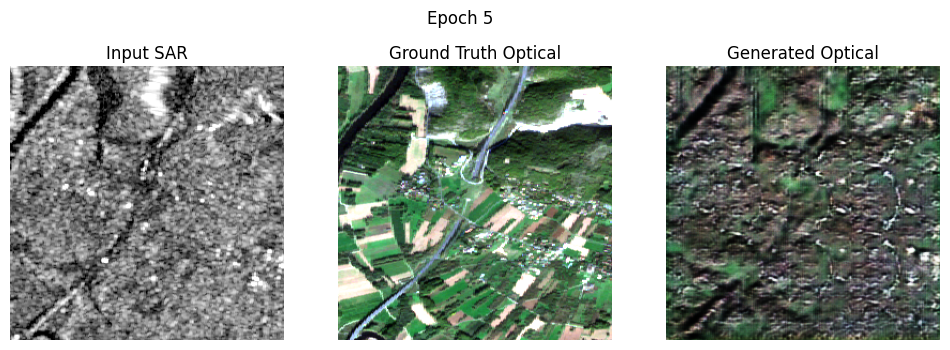

Checkpoint saved at epoch 5

Epoch 6/15 starting...
  batch 0 — gen_loss: 34.0527, disc_loss: 1.1459
  batch 50 — gen_loss: 32.0919, disc_loss: 0.1874
  batch 100 — gen_loss: 35.0077, disc_loss: 0.2313
  batch 150 — gen_loss: 30.6520, disc_loss: 0.5666
  batch 200 — gen_loss: 31.6334, disc_loss: 0.8997
  batch 250 — gen_loss: 29.0592, disc_loss: 1.2446
  batch 300 — gen_loss: 30.5780, disc_loss: 0.3699
  batch 350 — gen_loss: 32.3545, disc_loss: 1.3440
  batch 400 — gen_loss: 35.1373, disc_loss: 1.1365
  batch 450 — gen_loss: 28.1315, disc_loss: 1.3157
  batch 500 — gen_loss: 29.5144, disc_loss: 0.8444
  batch 550 — gen_loss: 33.2184, disc_loss: 2.4060
  batch 600 — gen_loss: 35.3042, disc_loss: 0.2864
  batch 650 — gen_loss: 29.2239, disc_loss: 1.3354
  batch 700 — gen_loss: 32.2179, disc_loss: 0.6287
  batch 750 — gen_loss: 22.6949, disc_loss: 0.7274
  batch 800 — gen_loss: 29.6447, disc_loss: 0.7696
  batch 850 — gen_loss: 29.4227, disc_loss: 0.8169
  batch 900 — gen_loss: 33.6410, 

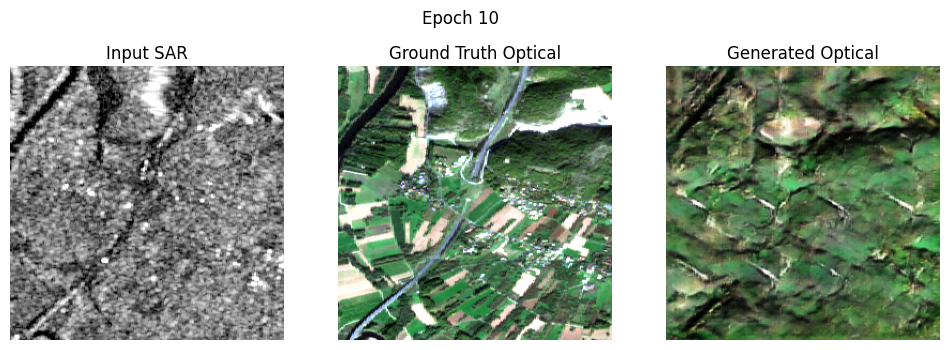

Checkpoint saved at epoch 10

Epoch 11/15 starting...
  batch 0 — gen_loss: 27.5164, disc_loss: 1.3017
  batch 50 — gen_loss: 31.4388, disc_loss: 0.4308
  batch 100 — gen_loss: 26.9790, disc_loss: 0.3007
  batch 150 — gen_loss: 28.0247, disc_loss: 1.1942
  batch 200 — gen_loss: 32.1717, disc_loss: 0.7370
  batch 250 — gen_loss: 33.0054, disc_loss: 0.6917
  batch 300 — gen_loss: 27.3494, disc_loss: 1.4840
  batch 350 — gen_loss: 33.0974, disc_loss: 0.2020
  batch 400 — gen_loss: 27.1816, disc_loss: 1.0541
  batch 450 — gen_loss: 27.3657, disc_loss: 0.5768
  batch 500 — gen_loss: 25.7618, disc_loss: 0.9102
  batch 550 — gen_loss: 25.8176, disc_loss: 1.0174
  batch 600 — gen_loss: 27.8308, disc_loss: 0.9137
  batch 650 — gen_loss: 34.4626, disc_loss: 0.1704
  batch 700 — gen_loss: 29.0945, disc_loss: 2.1938
  batch 750 — gen_loss: 27.4532, disc_loss: 0.9741
  batch 800 — gen_loss: 28.5213, disc_loss: 0.5576
  batch 850 — gen_loss: 31.8966, disc_loss: 0.6174
  batch 900 — gen_loss: 27.1508

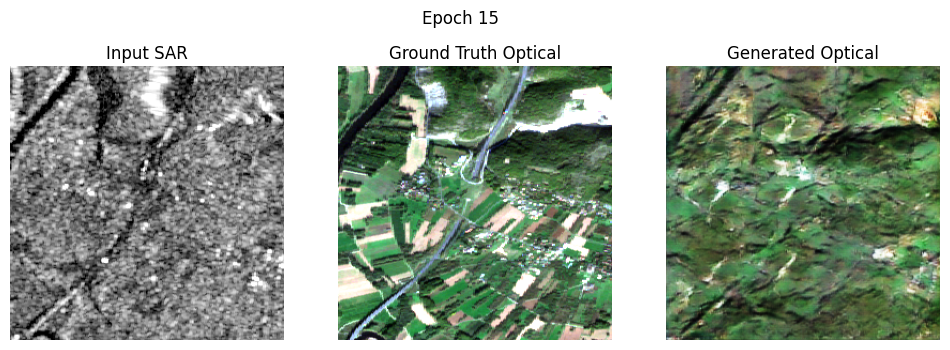

Checkpoint saved at epoch 15


In [12]:
import time

EPOCHS = 15

def fit(train_ds, val_ds, epochs):
    for epoch in range(epochs):
        start = time.time()
        gen_losses, disc_losses = [], []

        print(f"\nEpoch {epoch+1}/{epochs} starting...")
        for n, (input_image, target) in train_ds.enumerate():
            gen_loss, disc_loss = train_step(input_image, target)
            gen_losses.append(gen_loss)
            disc_losses.append(disc_loss)

            if n.numpy() % 50 == 0:  # print every 50 batches so you see live progress
                print(f"  batch {n.numpy()} — gen_loss: {gen_loss.numpy():.4f}, disc_loss: {disc_loss.numpy():.4f}")

        avg_gen_loss = tf.reduce_mean(gen_losses).numpy()
        avg_disc_loss = tf.reduce_mean(disc_losses).numpy()

        print(f"Epoch {epoch+1}/{epochs} DONE — gen_loss: {avg_gen_loss:.4f}, "
              f"disc_loss: {avg_disc_loss:.4f}, time: {time.time()-start:.1f}s")

        if (epoch + 1) % 5 == 0:
            generate_and_show(generator, fixed_sar, fixed_optical, epoch=epoch+1)
            checkpoint.save(file_prefix=checkpoint_prefix)
            print(f"Checkpoint saved at epoch {epoch+1}")

fit(train_dataset, val_dataset, EPOCHS)

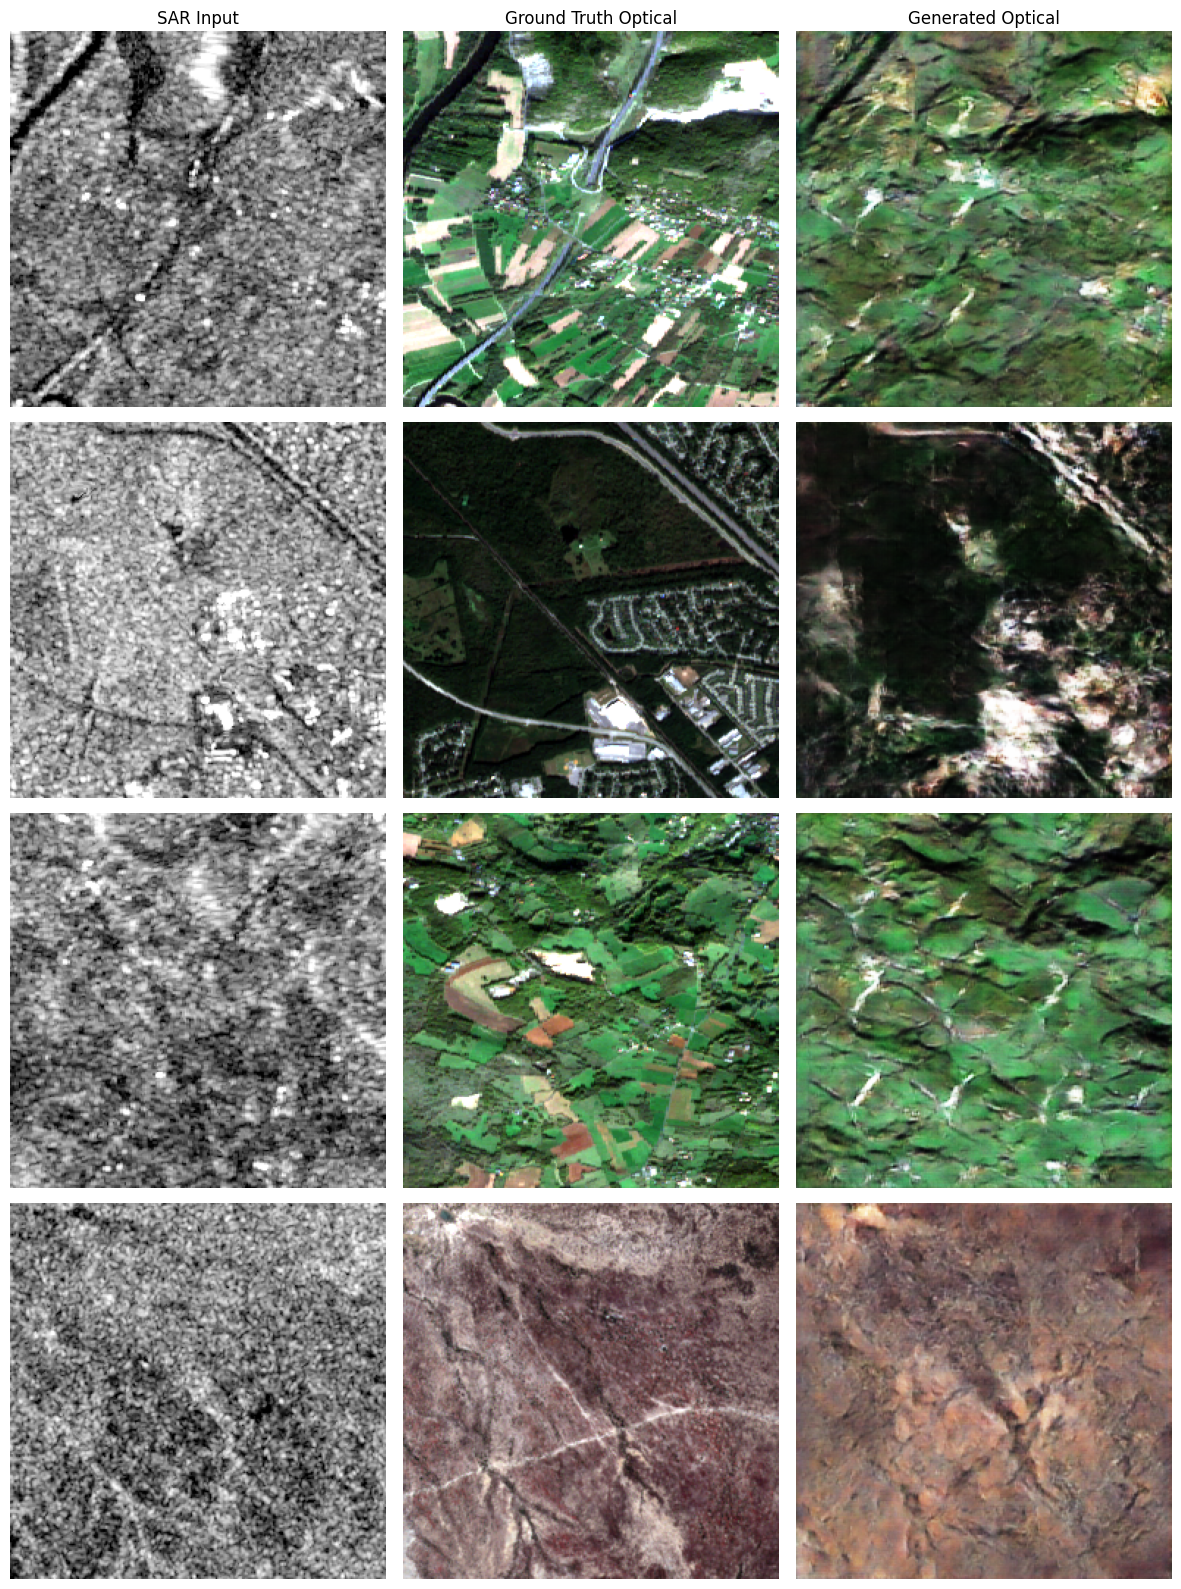

Saved sar2optical_results_grid.png — use this as your main results figure


In [14]:
n_examples = 4
fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))

for i, (sar, optical) in enumerate(val_dataset.unbatch().batch(1).take(n_examples)):
    generated = generator(sar, training=False)

    axes[i, 0].imshow(sar[0] * 0.5 + 0.5)
    axes[i, 0].set_title("SAR Input" if i == 0 else "")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(optical[0] * 0.5 + 0.5)
    axes[i, 1].set_title("Ground Truth Optical" if i == 0 else "")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(generated[0] * 0.5 + 0.5)
    axes[i, 2].set_title("Generated Optical" if i == 0 else "")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("sar2optical_results_grid.png", dpi=150)
plt.show()
print("Saved sar2optical_results_grid.png — use this as your main results figure")

In [15]:
generator.save("sar2optical_generator.keras")
print("Saved sar2optical_generator.keras")


reloaded_generator = tf.keras.models.load_model("sar2optical_generator.keras")
test_sar, test_optical = next(iter(val_dataset.take(1)))
test_output = reloaded_generator(test_sar, training=False)
print("Reload check passed — output shape:", test_output.shape)

Saved sar2optical_generator.keras
Reload check passed — output shape: (8, 256, 256, 3)


In [ ]:
import time

EPOCHS = 5
train_dataset_subset = train_dataset.take(400)

def fit(train_ds, val_ds, epochs):
    for epoch in range(epochs):
        start = time.time()
        gen_losses, disc_losses = [], []

        print(f"\nEpoch {epoch+1}/{epochs} starting...")
        for n, (input_image, target) in train_ds.enumerate():
            gen_loss, disc_loss = train_step(input_image, target)
            gen_losses.append(gen_loss)
            disc_losses.append(disc_loss)

            if n.numpy() % 20 == 0:  # print every 20 batches so you see live movement
                print(f"  batch {n.numpy()} — gen_loss: {gen_loss.numpy():.4f}, disc_loss: {disc_loss.numpy():.4f}")

        avg_gen_loss = tf.reduce_mean(gen_losses).numpy()
        avg_disc_loss = tf.reduce_mean(disc_losses).numpy()

        print(f"Epoch {epoch+1}/{epochs} DONE — gen_loss: {avg_gen_loss:.4f}, "
              f"disc_loss: {avg_disc_loss:.4f}, time: {time.time()-start:.1f}s")

        if (epoch + 1) % 5 == 0:
            generate_and_show(generator, fixed_sar, fixed_optical, epoch=epoch+1)
            checkpoint.save(file_prefix=checkpoint_prefix)
            print(f"Checkpoint saved at epoch {epoch+1}")

fit(train_dataset_subset, val_dataset, EPOCHS)


Epoch 1/5 starting...
  batch 0 — gen_loss: 26.2637, disc_loss: 1.8455
  batch 20 — gen_loss: 26.8351, disc_loss: 0.8600
  batch 40 — gen_loss: 26.2668, disc_loss: 1.5793
  batch 60 — gen_loss: 31.0715, disc_loss: 0.2068
  batch 80 — gen_loss: 25.9214, disc_loss: 0.7042
  batch 100 — gen_loss: 25.7488, disc_loss: 0.4690
  batch 120 — gen_loss: 26.2147, disc_loss: 0.7682
  batch 140 — gen_loss: 26.1033, disc_loss: 0.5414
  batch 160 — gen_loss: 25.5761, disc_loss: 0.6551
  batch 180 — gen_loss: 26.8527, disc_loss: 1.7310
  batch 200 — gen_loss: 25.2453, disc_loss: 0.5092
  batch 220 — gen_loss: 23.1220, disc_loss: 1.5171
  batch 240 — gen_loss: 30.0567, disc_loss: 1.1747
  batch 260 — gen_loss: 29.9569, disc_loss: 0.8275
  batch 280 — gen_loss: 23.1152, disc_loss: 0.5274
  batch 300 — gen_loss: 28.8255, disc_loss: 0.3390
  batch 320 — gen_loss: 26.7910, disc_loss: 0.6068
  batch 340 — gen_loss: 24.2992, disc_loss: 0.6408
  batch 360 — gen_loss: 26.0129, disc_loss: 1.2297
  batch 380 — 

In [ ]:
final_ssim, final_psnr = evaluate_generator(generator, val_dataset)
print(f"SSIM: {final_ssim:.4f}, PSNR: {final_psnr:.2f} dB")

In [ ]:
n_examples = 4
fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))

for i, (sar, optical) in enumerate(val_dataset.unbatch().batch(1).take(n_examples)):
    generated = generator(sar, training=False)
    axes[i, 0].imshow(sar[0] * 0.5 + 0.5); axes[i, 0].set_title("SAR Input" if i==0 else ""); axes[i, 0].axis("off")
    axes[i, 1].imshow(optical[0] * 0.5 + 0.5); axes[i, 1].set_title("Ground Truth" if i==0 else ""); axes[i, 1].axis("off")
    axes[i, 2].imshow(generated[0] * 0.5 + 0.5); axes[i, 2].set_title("Generated" if i==0 else ""); axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("sar2optical_results_grid.png", dpi=150)
plt.show()

In [ ]:
generator.save("sar2optical_generator.keras")
print("Saved.")